# 01 — Data Exploration & Preparation

**Goal:** download the raw retailer data, understand it, and build a clean weekly
modeling table (`model_data.csv`) that notebook 02 will feed into the MMM.

**How to use:** run each cell with **Shift+Enter**, top to bottom. Read the comments —
they explain both the Python and the marketing logic.

In [1]:
# Imports: bring in the libraries we need.
# pandas = spreadsheets-in-Python (tables called "DataFrames")
# matplotlib = plotting
import pandas as pd
import matplotlib.pyplot as plt

# Make plots a bit larger by default
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
# Download the dataset straight from GitHub (runs once; then we save a local copy).
URL = "https://raw.githubusercontent.com/sibylhe/mmm_stan/main/data.csv"
df = pd.read_csv(URL, parse_dates=["wk_strt_dt"])  # parse_dates -> treat that column as real dates

df.to_csv("../data/raw_data.csv", index=False)     # local backup so you can work offline
print("Rows (weeks):", len(df))
print("Columns:", len(df.columns))
print("Date range:", df["wk_strt_dt"].min().date(), "to", df["wk_strt_dt"].max().date())

Rows (weeks): 209
Columns: 80
Date range: 2014-08-03 to 2018-07-29


In [3]:
# Look at the first few rows. .head() shows the top 5.
# 80+ columns is overwhelming — the data dictionary (data/DATA_DICTIONARY.md) explains the groups.
df.head()

,wk_strt_dt,yr_nbr,qtr_nbr,prd,wk_nbr,wk_in_yr_nbr,mdip_dm,mdip_inst,mdip_nsp,mdip_auddig,...,seas_prd_12,seas_week_40,seas_week_41,seas_week_42,seas_week_43,seas_week_44,seas_week_45,seas_week_46,seas_week_47,seas_week_48
0,2014-08-03,2014,3,7,1,27,4863885,29087520,2421933,692315,...,0,0,0,0,0,0,0,0,0,0
1,2014-08-10,2014,3,7,2,28,20887502,8345120,3984494,475810,...,0,0,0,0,0,0,0,0,0,0
2,2014-08-17,2014,3,7,3,29,11097724,17276800,1846832,784732,...,0,0,0,0,0,0,0,0,0,0
3,2014-08-24,2014,3,7,4,30,1023446,18468480,2394834,1032301,...,0,0,0,0,0,0,0,0,0,0
4,2014-08-31,2014,3,8,1,31,21109811,26659920,3312008,400456,...,0,0,0,0,0,0,0,0,0,0


## Step 1 — Pick our columns

The raw file has media **spend** (`mdsp_*`), media **impressions** (`mdip_*`), macro
controls, promo markdowns, holiday flags and seasonality dummies.

We model with **spend** (that's what a budget decision controls) and group
10 channels into 7 to keep the model stable — see the data dictionary for why.

In [4]:
# Group the 10 raw spend columns into 7 marketing channels.
# In Python, a "dict" maps a name -> a list of columns to add together.
channel_groups = {
    "tv":            ["mdsp_vidtr"],
    "digital_video": ["mdsp_viddig"],
    "search":        ["mdsp_sem"],
    "social":        ["mdsp_so"],
    "display":       ["mdsp_on"],
    "audio":         ["mdsp_audtr", "mdsp_auddig"],
    "print_mail":    ["mdsp_dm", "mdsp_inst", "mdsp_nsp"],
}

# Build the modeling table
model_df = pd.DataFrame()
model_df["date"] = df["wk_strt_dt"]
for channel, cols in channel_groups.items():
    model_df[channel] = df[cols].sum(axis=1)   # axis=1 -> sum across columns, row by row

# Target variable (what we want to explain)
model_df["sales"] = df["sales"]

# Control variables: things that move sales but aren't media
model_df["consumer_sentiment"] = df["me_ics_all"]
model_df["gas_price"]          = df["me_gas_dpg"]
model_df["store_count"]        = df["st_ct"]
model_df["markdown"]           = df["mrkdn_valadd_edw"] + df["mrkdn_pdm"]

# A few high-impact holiday flags (already 0/1 dummies in the raw data)
model_df["hol_blackfriday"]  = df["hldy_Black Friday"]
model_df["hol_christmas"]    = df["hldy_Christmas Day"]
model_df["hol_thanksgiving"] = df["hldy_Thanksgiving"]
model_df["hol_july4"]        = df["hldy_July 4th"]
model_df["hol_primeday"]     = df["hldy_Prime Day"]

model_df.head()

,date,tv,digital_video,search,social,display,audio,print_mail,sales,consumer_sentiment,gas_price,store_count,markdown,hol_blackfriday,hol_christmas,hol_thanksgiving,hol_july4,hol_primeday
0,2014-08-03,216725.59,45397.90,355954.51,0.0,61364.75,256834.83,1315805.08,72051457.64,82.5,3.595,716.285714,0.368029,0,0,0,0,0
1,2014-08-10,108919.26,2903.36,336306.72,0.0,132643.90,111642.33,1357172.41,78794770.54,82.5,3.582,716.428571,0.360911,0,0,0,0,0
2,2014-08-17,74032.19,8110.48,344787.96,0.0,76741.27,61622.35,2259591.41,70071185.56,82.5,3.549,717.000000,0.344832,0,0,0,0,0
3,2014-08-24,110995.66,6516.22,365495.11,0.0,193043.55,184043.37,634320.59,68642464.59,82.5,3.532,717.000000,0.356973,0,0,0,0,0
4,2014-08-31,225140.84,19381.12,401789.35,0.0,249612.89,149284.88,3233659.55,86190784.65,84.6,3.536,717.000000,0.359990,0,0,0,0,0


## Step 2 — Look at the data (EDA)

Before modeling, always *look*. You're checking for trends, seasonality, and anything weird.

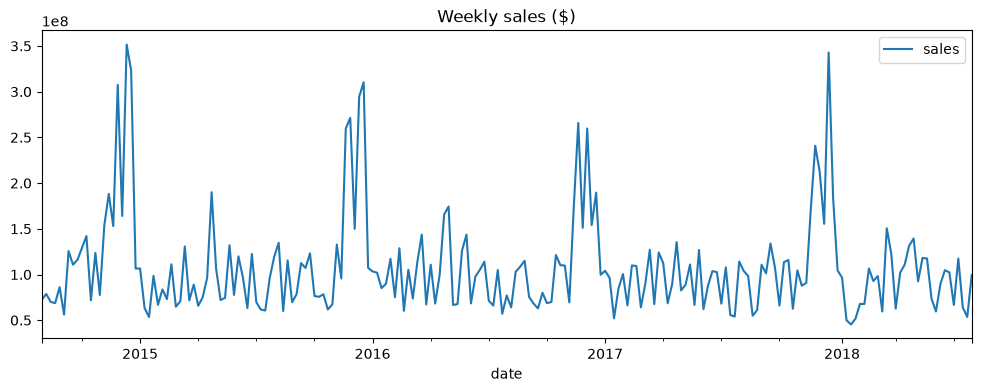

In [5]:
# Weekly sales over time. Notice the huge spikes — those are holiday weeks.
model_df.plot(x="date", y="sales", title="Weekly sales ($)")
plt.show()

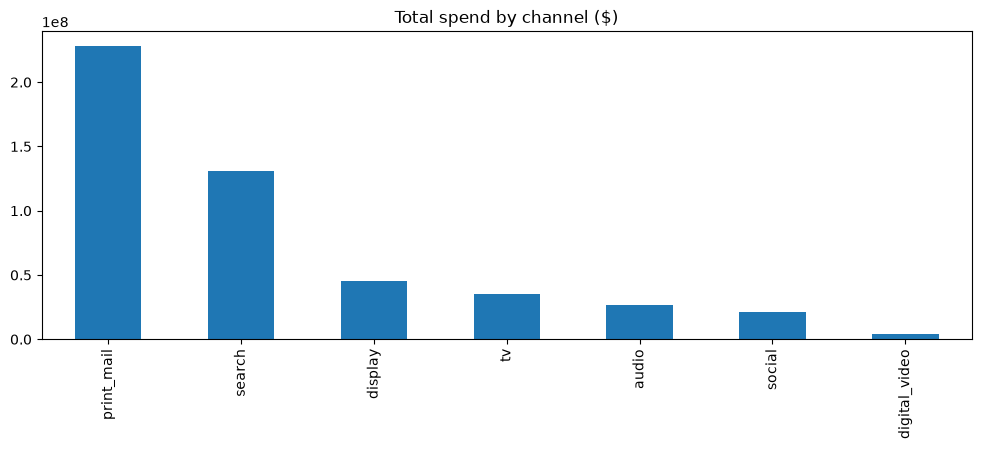

print_mail       46.5 %
search           26.7 %
display           9.2 %
tv                7.2 %
audio             5.4 %
social            4.3 %
digital_video     0.8 %
dtype: str


In [6]:
# How is the media budget split? Total spend per channel over the whole period.
channels = list(channel_groups.keys())
totals = model_df[channels].sum().sort_values(ascending=False)

totals.plot(kind="bar", title="Total spend by channel ($)")
plt.show()

# Share of budget as percentages
print((totals / totals.sum() * 100).round(1).astype(str) + " %")

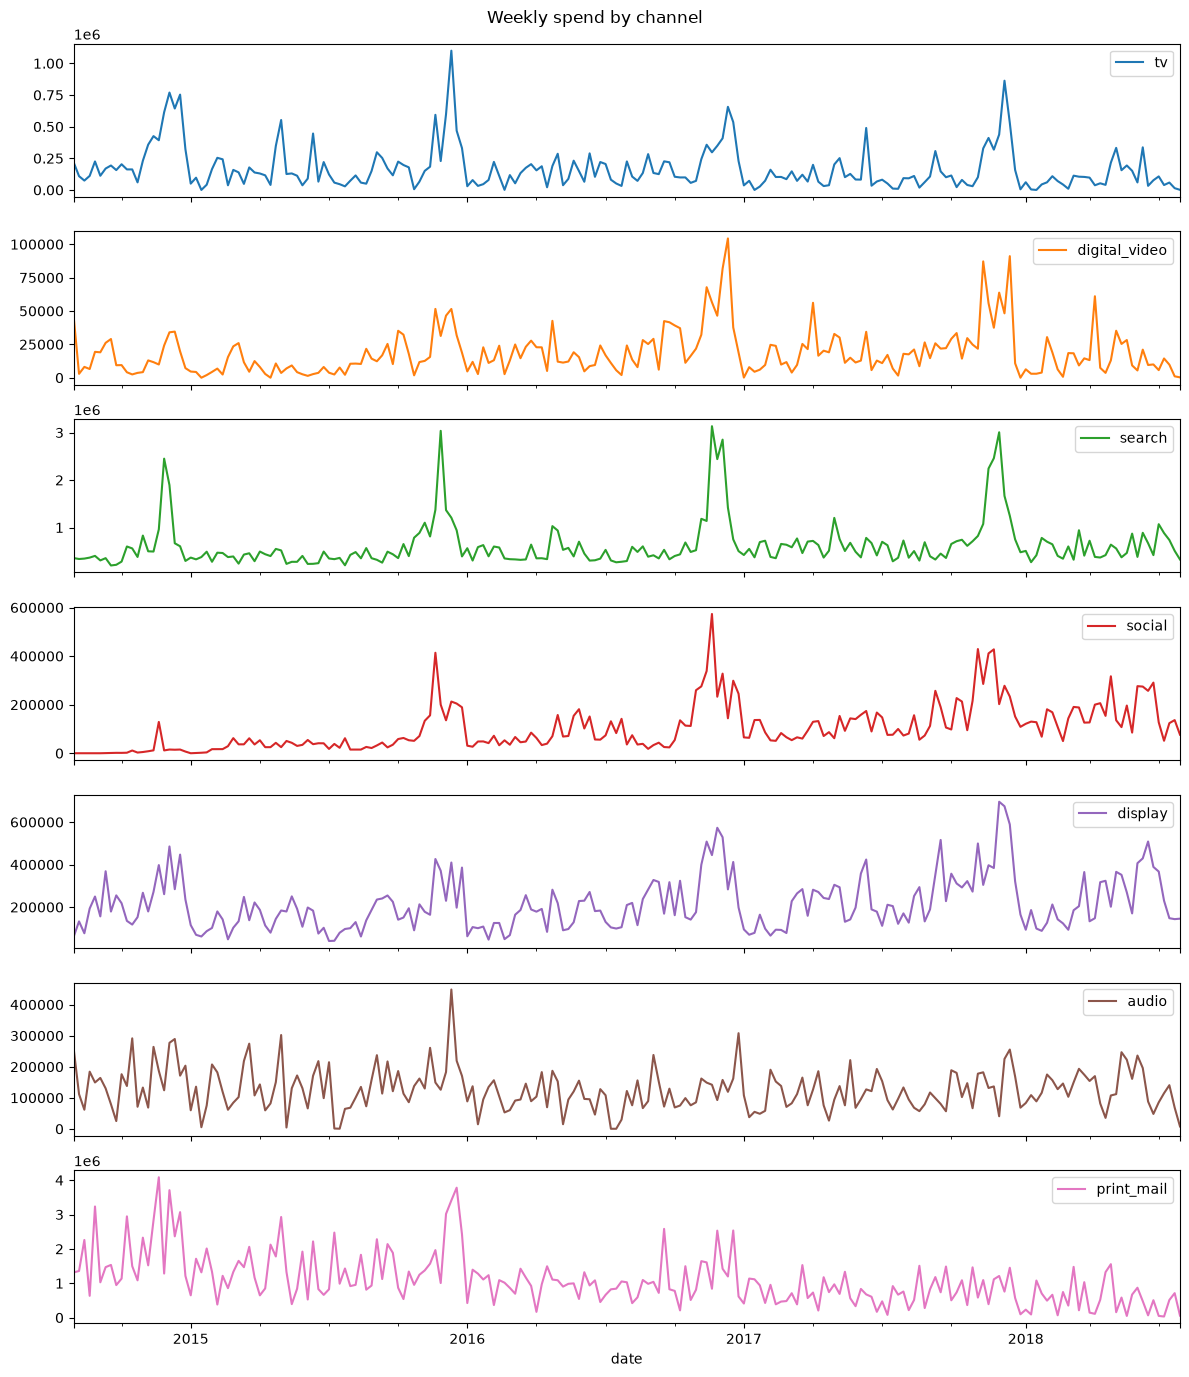

In [7]:
# Spend over time per channel — is spending steady or bursty ("flighted")?
model_df.plot(x="date", y=channels, subplots=True, figsize=(12, 14), title="Weekly spend by channel")
plt.tight_layout()
plt.show()

In [8]:
# Correlation between channels. If two channels always move together (corr > ~0.8),
# the model struggles to tell their effects apart (multicollinearity) — an interview topic!
corr = model_df[channels].corr().round(2)
corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

,tv,digital_video,search,social,display,audio,print_mail
tv,1.000000,0.550000,0.480000,0.240000,0.550000,0.520000,0.520000
digital_video,0.550000,1.000000,0.560000,0.470000,0.560000,0.260000,0.100000
search,0.480000,0.560000,1.000000,0.550000,0.560000,0.150000,0.120000
social,0.240000,0.470000,0.550000,1.000000,0.580000,0.130000,-0.120000
display,0.550000,0.560000,0.560000,0.580000,1.000000,0.270000,0.140000
audio,0.520000,0.260000,0.150000,0.130000,0.270000,1.000000,0.280000
print_mail,0.520000,0.100000,0.120000,-0.120000,0.140000,0.280000,1.000000


## Step 3 — Save the modeling table

Write your own observations in the cell at the bottom before moving on — that habit is what turns a tutorial into *your* project.

In [9]:
model_df.to_csv("../data/model_data.csv", index=False)
print("Saved ../data/model_data.csv  —  shape:", model_df.shape)
print("Ready for notebook 02.")

Saved ../data/model_data.csv  —  shape: (209, 18)
Ready for notebook 02.


### My observations (fill this in!)

- Biggest channel by spend: ...
- Sales seasonality pattern: ...
- Channels that look highly correlated: ...
- Anything surprising: ...